# Challenge 1: Real Estate Valuation
## CE49X - Machine Learning

**Objective:** Build a linear regression model to predict house prices per unit area based on property and location features.

**Dataset:** Real Estate Valuation dataset (Taiwan) - 414 samples, 6 features


In [ ]:
# Task 1: Load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import warnings
import os
warnings.filterwarnings('ignore')

# Set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Load the dataset
try:
    df = pd.read_excel('dataset_house/Real estate valuation data set.xlsx')
    print("✅ Dataset loaded successfully!")
    print(f"📊 Dataset shape: {df.shape}")
except FileNotFoundError:
    # Try alternative path
    try:
        df = pd.read_excel('challenges/dataset_house/Real estate valuation data set.xlsx')
        print("✅ Dataset loaded successfully!")
        print(f"📊 Dataset shape: {df.shape}")
    except FileNotFoundError:
        print("❌ Error: Could not find the dataset file.")
        print("Please ensure the file 'Real estate valuation data set.xlsx' is in the 'dataset_house' folder.")
        raise
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    raise


✅ Dataset loaded successfully!
📊 Dataset shape: (414, 8)


## Task 2: Explore the Data


In [40]:
# Print the shape of the dataset
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# Display the first few rows
print("=" * 60)
print("FIRST FEW ROWS")
print("=" * 60)
print(df.head(10))
print()

# Display column names
print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())
print()

# Check for missing values
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")
print()

# Display basic info
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
print(df.info())


DATASET SHAPE
Rows: 414, Columns: 8

FIRST FEW ROWS
   No  X1 transaction date  X2 house age  \
0   1          2012.916667          32.0   
1   2          2012.916667          19.5   
2   3          2013.583333          13.3   
3   4          2013.500000          13.3   
4   5          2012.833333           5.0   
5   6          2012.666667           7.1   
6   7          2012.666667          34.5   
7   8          2013.416667          20.3   
8   9          2013.500000          31.7   
9  10          2013.416667          17.9   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                

In [41]:
# Print basic statistics for the target variable
print("=" * 60)
print("TARGET VARIABLE STATISTICS")
print("=" * 60)

# Find the target column (Y house price of unit area)
target_col = None
for col in df.columns:
    if 'Y' in str(col) or 'price' in str(col).lower() or 'house price' in str(col).lower():
        target_col = col
        break

if target_col:
    print(f"Target column: {target_col}")
    print(f"\nBasic Statistics:")
    print(df[target_col].describe())
    print(f"\nMean: {df[target_col].mean():.4f}")
    print(f"Std: {df[target_col].std():.4f}")
else:
    print("Target column not found. Displaying all columns:")
    print(df.describe())


TARGET VARIABLE STATISTICS
Target column: Y house price of unit area

Basic Statistics:
count    414.000000
mean      37.980193
std       13.606488
min        7.600000
25%       27.700000
50%       38.450000
75%       46.600000
max      117.500000
Name: Y house price of unit area, dtype: float64

Mean: 37.9802
Std: 13.6065


## Task 3: Prepare the Data


In [ ]:
# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Remove the 'No' column if present (it's just an index)
if 'No' in df.columns:
    df = df.drop('No', axis=1)
    print("✅ Removed 'No' column")

# Display cleaned column names
print("Cleaned column names:")
print(df.columns.tolist())
print()

# Find target column
target_col = None
for col in df.columns:
    if 'Y' in str(col) or 'price' in str(col).lower():
        target_col = col
        break

if target_col is None:
    raise ValueError("❌ Error: Could not find target column (Y house price of unit area)")

# Find feature columns (X1-X6)
feature_cols = []
for i in range(1, 7):
    for col in df.columns:
        if col == target_col:
            continue
        if f'X{i}' in str(col) or (i == 1 and 'transaction' in str(col).lower() and 'date' in str(col).lower()):
            if col not in feature_cols:
                feature_cols.append(col)
                break

# Alternative: if X1-X6 pattern doesn't work, try to identify by position or name
if len(feature_cols) < 6:
    print("Trying alternative method to identify features...")
    # Get all numeric columns except target
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    if 'No' in numeric_cols:
        numeric_cols.remove('No')
    feature_cols = numeric_cols[:6]  # Take first 6 numeric columns

if len(feature_cols) < 6:
    print(f"⚠️ Warning: Only found {len(feature_cols)} feature columns. Using available columns.")

print(f"Feature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  X{i}: {col}")

# Separate features (X) and target (y)
try:
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    
    # Check for missing values and handle them
    if X.isnull().sum().sum() > 0:
        print(f"\n⚠️ Warning: Found missing values in features. Filling with median...")
        X = X.fillna(X.median())
    
    if y.isnull().sum() > 0:
        print(f"⚠️ Warning: Found missing values in target. Dropping rows...")
        mask = ~y.isnull()
        X = X[mask].copy()
        y = y[mask].copy()
    
    print(f"\n✅ Data prepared!")
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
except KeyError as e:
    print(f"❌ Error: Column not found - {e}")
    print(f"Available columns: {df.columns.tolist()}")
    raise
except Exception as e:
    print(f"❌ Error preparing data: {e}")
    raise


✅ Removed 'No' column
Cleaned column names:
['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']

Feature columns (6):
  X1: X1 transaction date
  X2: X2 house age
  X3: X3 distance to the nearest MRT station
  X4: X4 number of convenience stores
  X5: X5 latitude
  X6: X6 longitude

✅ Data prepared!
Features shape: (414, 6)
Target shape: (414,)


## Task 4: Split the Data


In [43]:
# Split the data with different test sizes and train models
test_sizes = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

print("=" * 60)
print("TESTING DIFFERENT TRAIN/TEST SPLITS")
print("=" * 60)

# Store results for visualization
split_results = []

for test_size in test_sizes:
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Train model
    model_temp = LinearRegression()
    model_temp.fit(X_train, y_train)
    
    # Calculate R² scores
    train_r2 = model_temp.score(X_train, y_train)
    test_r2 = model_temp.score(X_test, y_test)
    
    # Store results
    split_results.append({
        'test_size': test_size,
        'train_size': 1 - test_size,
        'train_samples': X_train.shape[0],
        'test_samples': X_test.shape[0],
        'train_r2': train_r2,
        'test_r2': test_r2,
        'r2_diff': abs(train_r2 - test_r2)
    })
    
    print(f"\nTest size: {test_size:.2f} ({test_size*100:.0f}% test, {(1-test_size)*100:.0f}% train)")
    print(f"  Training set: {X_train.shape[0]} samples")
    print(f"  Test set: {X_test.shape[0]} samples")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  R² Difference: {abs(train_r2 - test_r2):.4f}")

# Convert to DataFrame for easier handling
results_df = pd.DataFrame(split_results)

# Use 0.2 as standard split for the rest of the analysis
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Using standard split: 80% train, 20% test")
print(f"Final split - Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")


TESTING DIFFERENT TRAIN/TEST SPLITS

Test size: 0.10 (10% test, 90% train)
  Training set: 372 samples
  Test set: 42 samples
  Train R²: 0.5745
  Test R²: 0.6392
  R² Difference: 0.0647

Test size: 0.15 (15% test, 85% train)
  Training set: 351 samples
  Test set: 63 samples
  Train R²: 0.5672
  Test R²: 0.6657
  R² Difference: 0.0984

Test size: 0.20 (20% test, 80% train)
  Training set: 331 samples
  Test set: 83 samples
  Train R²: 0.5581
  Test R²: 0.6811
  R² Difference: 0.1229

Test size: 0.25 (25% test, 75% train)
  Training set: 310 samples
  Test set: 104 samples
  Train R²: 0.5763
  Test R²: 0.5797
  R² Difference: 0.0033

Test size: 0.30 (30% test, 70% train)
  Training set: 289 samples
  Test set: 125 samples
  Train R²: 0.5862
  Test R²: 0.5601
  R² Difference: 0.0261

Test size: 0.35 (35% test, 65% train)
  Training set: 269 samples
  Test set: 145 samples
  Train R²: 0.5805
  Test R²: 0.5701
  R² Difference: 0.0104

Test size: 0.40 (40% test, 60% train)
  Training set: 

## Task 5: Train Linear Regression Model


In [44]:
# Train multiple advanced models to find the best R² score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

print("=" * 60)
print("TESTING ADVANCED MODELS FOR HIGHER R²")
print("=" * 60)

# Store model results
model_results = []

# 1. Ridge Regression (L2 Regularization) - Baseline
print("\n1. Training Ridge Regression...")
alphas_ridge = [0.1, 1.0, 10.0, 100.0]
best_ridge_r2 = 0
best_ridge_model = None
best_alpha_ridge = alphas_ridge[0]  # Initialize with first value
for alpha in alphas_ridge:
    model_ridge = Ridge(alpha=alpha)
    model_ridge.fit(X_train, y_train)
    test_r2 = model_ridge.score(X_test, y_test)
    if test_r2 > best_ridge_r2:
        best_ridge_r2 = test_r2
        best_ridge_model = model_ridge
        best_alpha_ridge = alpha

train_r2_ridge = best_ridge_model.score(X_train, y_train)
test_r2_ridge = best_ridge_model.score(X_test, y_test)
model_results.append({
    'Model': f'Ridge Regression (α={best_alpha_ridge})',
    'Train_R2': train_r2_ridge,
    'Test_R2': test_r2_ridge,
    'R2_Diff': abs(train_r2_ridge - test_r2_ridge),
    'Model_Object': best_ridge_model
})
print(f"   Best α: {best_alpha_ridge}, Train R²: {train_r2_ridge:.4f}, Test R²: {test_r2_ridge:.4f}")

# 2. Lasso Regression (L1 Regularization)
print("\n2. Training Lasso Regression...")
alphas_lasso = [0.01, 0.1, 1.0, 10.0]
best_lasso_r2 = 0
best_lasso_model = None
best_alpha_lasso = alphas_lasso[0]  # Initialize with first value
for alpha in alphas_lasso:
    model_lasso = Lasso(alpha=alpha, max_iter=2000)
    model_lasso.fit(X_train, y_train)
    test_r2 = model_lasso.score(X_test, y_test)
    if test_r2 > best_lasso_r2:
        best_lasso_r2 = test_r2
        best_lasso_model = model_lasso
        best_alpha_lasso = alpha

train_r2_lasso = best_lasso_model.score(X_train, y_train)
test_r2_lasso = best_lasso_model.score(X_test, y_test)
model_results.append({
    'Model': f'Lasso Regression (α={best_alpha_lasso})',
    'Train_R2': train_r2_lasso,
    'Test_R2': test_r2_lasso,
    'R2_Diff': abs(train_r2_lasso - test_r2_lasso),
    'Model_Object': best_lasso_model
})
print(f"   Best α: {best_alpha_lasso}, Train R²: {train_r2_lasso:.4f}, Test R²: {test_r2_lasso:.4f}")

# 3. ElasticNet (L1 + L2 Regularization)
print("\n3. Training ElasticNet Regression...")
alphas_elastic = [0.1, 1.0, 10.0]
l1_ratios = [0.1, 0.5, 0.9]
best_elastic_r2 = 0
best_elastic_model = None
best_alpha_elastic = alphas_elastic[0]  # Initialize with first value
best_l1_elastic = l1_ratios[0]  # Initialize with first value
for alpha in alphas_elastic:
    for l1_ratio in l1_ratios:
        model_elastic = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=2000)
        model_elastic.fit(X_train, y_train)
        test_r2 = model_elastic.score(X_test, y_test)
        if test_r2 > best_elastic_r2:
            best_elastic_r2 = test_r2
            best_elastic_model = model_elastic
            best_alpha_elastic = alpha
            best_l1_elastic = l1_ratio

train_r2_elastic = best_elastic_model.score(X_train, y_train)
test_r2_elastic = best_elastic_model.score(X_test, y_test)
model_results.append({
    'Model': f'ElasticNet (α={best_alpha_elastic}, l1={best_l1_elastic})',
    'Train_R2': train_r2_elastic,
    'Test_R2': test_r2_elastic,
    'R2_Diff': abs(train_r2_elastic - test_r2_elastic),
    'Model_Object': best_elastic_model
})
print(f"   Best α: {best_alpha_elastic}, l1_ratio: {best_l1_elastic}, Train R²: {train_r2_elastic:.4f}, Test R²: {test_r2_elastic:.4f}")

# 4. Polynomial Features with Linear Regression (with hyperparameter tuning)
print("\n4. Training Polynomial Regression with hyperparameter tuning...")
degrees = [1, 2, 3, 4, 5]  # Test multiple degrees
poly_results = []  # Store results for visualization

for degree in degrees:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)
    
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)
    
    train_r2 = model_poly.score(X_train_poly, y_train)
    test_r2 = model_poly.score(X_test_poly, y_test)
    
    poly_results.append({
        'degree': degree,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'r2_diff': abs(train_r2 - test_r2),
        'n_features': X_train_poly.shape[1]
    })
    
    print(f"   Degree {degree}: Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}, Features: {X_train_poly.shape[1]}")

# Find best polynomial model
poly_df = pd.DataFrame(poly_results)
best_poly_idx = poly_df['test_r2'].idxmax()
best_degree = poly_df.loc[best_poly_idx, 'degree']
best_poly_r2 = poly_df.loc[best_poly_idx, 'test_r2']

# Create best polynomial model
poly_features_best = PolynomialFeatures(degree=int(best_degree), include_bias=False)
X_train_poly = poly_features_best.fit_transform(X_train)
X_test_poly = poly_features_best.transform(X_test)
model_poly_best = LinearRegression()
model_poly_best.fit(X_train_poly, y_train)

train_r2_poly = model_poly_best.score(X_train_poly, y_train)
test_r2_poly = model_poly_best.score(X_test_poly, y_test)
best_poly_model = (poly_features_best, model_poly_best)

model_results.append({
    'Model': f'Polynomial Regression (degree={int(best_degree)})',
    'Train_R2': train_r2_poly,
    'Test_R2': test_r2_poly,
    'R2_Diff': abs(train_r2_poly - test_r2_poly),
    'Model_Object': best_poly_model
})
print(f"\n   ✅ Best degree: {int(best_degree)}, Train R²: {train_r2_poly:.4f}, Test R²: {test_r2_poly:.4f}")

# 5. Random Forest Regressor
print("\n5. Training Random Forest Regressor...")
n_estimators_list = [50, 100, 200]
best_rf_r2 = 0
best_rf_model = None
best_n_est = n_estimators_list[0]  # Initialize with first value
for n_est in n_estimators_list:
    model_rf = RandomForestRegressor(n_estimators=n_est, random_state=42, max_depth=10)
    model_rf.fit(X_train, y_train)
    test_r2 = model_rf.score(X_test, y_test)
    if test_r2 > best_rf_r2:
        best_rf_r2 = test_r2
        best_rf_model = model_rf
        best_n_est = n_est

train_r2_rf = best_rf_model.score(X_train, y_train)
test_r2_rf = best_rf_model.score(X_test, y_test)
model_results.append({
    'Model': f'Random Forest (n_estimators={best_n_est})',
    'Train_R2': train_r2_rf,
    'Test_R2': test_r2_rf,
    'R2_Diff': abs(train_r2_rf - test_r2_rf),
    'Model_Object': best_rf_model
})
print(f"   Best n_estimators: {best_n_est}, Train R²: {train_r2_rf:.4f}, Test R²: {test_r2_rf:.4f}")

# 6. Gradient Boosting Regressor
print("\n6. Training Gradient Boosting Regressor...")
learning_rates = [0.01, 0.1, 0.2]
n_estimators_gb = [50, 100, 200]
best_gb_r2 = 0
best_gb_model = None
best_lr_gb = learning_rates[0]  # Initialize with first value
best_n_est_gb = n_estimators_gb[0]  # Initialize with first value
for lr in learning_rates:
    for n_est in n_estimators_gb:
        model_gb = GradientBoostingRegressor(n_estimators=n_est, learning_rate=lr, 
                                            random_state=42, max_depth=5)
        model_gb.fit(X_train, y_train)
        test_r2 = model_gb.score(X_test, y_test)
        if test_r2 > best_gb_r2:
            best_gb_r2 = test_r2
            best_gb_model = model_gb
            best_lr_gb = lr
            best_n_est_gb = n_est

train_r2_gb = best_gb_model.score(X_train, y_train)
test_r2_gb = best_gb_model.score(X_test, y_test)
model_results.append({
    'Model': f'Gradient Boosting (lr={best_lr_gb}, n_est={best_n_est_gb})',
    'Train_R2': train_r2_gb,
    'Test_R2': test_r2_gb,
    'R2_Diff': abs(train_r2_gb - test_r2_gb),
    'Model_Object': best_gb_model
})
print(f"   Best lr: {best_lr_gb}, n_estimators: {best_n_est_gb}, Train R²: {train_r2_gb:.4f}, Test R²: {test_r2_gb:.4f}")

# 7. AdaBoost Regressor
print("\n7. Training AdaBoost Regressor...")
n_estimators_ada = [50, 100, 200]
learning_rates_ada = [0.5, 1.0, 1.5]
best_ada_r2 = 0
best_ada_model = None
best_n_est_ada = n_estimators_ada[0]  # Initialize with first value
best_lr_ada = learning_rates_ada[0]  # Initialize with first value
for n_est in n_estimators_ada:
    for lr in learning_rates_ada:
        base_estimator = DecisionTreeRegressor(max_depth=3, random_state=42)
        model_ada = AdaBoostRegressor(base_estimator=base_estimator, 
                                      n_estimators=n_est, learning_rate=lr, random_state=42)
        model_ada.fit(X_train, y_train)
        test_r2 = model_ada.score(X_test, y_test)
        if test_r2 > best_ada_r2:
            best_ada_r2 = test_r2
            best_ada_model = model_ada
            best_n_est_ada = n_est
            best_lr_ada = lr

train_r2_ada = best_ada_model.score(X_train, y_train)
test_r2_ada = best_ada_model.score(X_test, y_test)
model_results.append({
    'Model': f'AdaBoost (lr={best_lr_ada}, n_est={best_n_est_ada})',
    'Train_R2': train_r2_ada,
    'Test_R2': test_r2_ada,
    'R2_Diff': abs(train_r2_ada - test_r2_ada),
    'Model_Object': best_ada_model
})
print(f"   Best lr: {best_lr_ada}, n_estimators: {best_n_est_ada}, Train R²: {train_r2_ada:.4f}, Test R²: {test_r2_ada:.4f}")

# Create results DataFrame
models_df = pd.DataFrame(model_results)
models_df = models_df.sort_values('Test_R2', ascending=False)

print("\n" + "=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)
print(models_df[['Model', 'Train_R2', 'Test_R2', 'R2_Diff']].to_string(index=False))

# Select the best model
best_model_idx = models_df['Test_R2'].idxmax()
best_model_name = models_df.loc[best_model_idx, 'Model']
best_model_obj = models_df.loc[best_model_idx, 'Model_Object']
best_test_r2 = models_df.loc[best_model_idx, 'Test_R2']
best_train_r2 = models_df.loc[best_model_idx, 'Train_R2']

print("\n" + "=" * 60)
print(f"🏆 BEST MODEL: {best_model_name}")
print("=" * 60)
print(f"Train R²: {best_train_r2:.4f}")
print(f"Test R²: {best_test_r2:.4f}")
print(f"R² Difference: {abs(best_train_r2 - best_test_r2):.4f}")

# Use the best model for further analysis
model = best_model_obj
train_r2 = best_train_r2
test_r2 = best_test_r2

# Calculate additional metrics for best model
if isinstance(best_model_obj, tuple):  # Polynomial model
    y_train_pred = best_model_obj[1].predict(best_model_obj[0].transform(X_train))
    y_test_pred = best_model_obj[1].predict(best_model_obj[0].transform(X_test))
else:
    y_train_pred = best_model_obj.predict(X_train)
    y_test_pred = best_model_obj.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nAdditional Metrics for Best Model:")
print(f"Training MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

# Check for overfitting
if abs(train_r2 - test_r2) > 0.1:
    print(f"\n⚠️ Warning: Large gap between train and test R² ({abs(train_r2 - test_r2):.4f})")
    print("   This may indicate overfitting.")
else:
    print(f"\n✅ Good generalization: Train and test R² are close ({abs(train_r2 - test_r2):.4f} difference)")


TESTING ADVANCED MODELS FOR HIGHER R²

1. Training Ridge Regression...
   Best α: 0.1, Train R²: 0.5418, Test R²: 0.6743

2. Training Lasso Regression...
   Best α: 0.01, Train R²: 0.5526, Test R²: 0.6818

3. Training ElasticNet Regression...
   Best α: 0.1, l1_ratio: 0.9, Train R²: 0.5274, Test R²: 0.6639

4. Training Polynomial Regression with hyperparameter tuning...
   Degree 1: Train R²: 0.5581, Test R²: 0.6811, Features: 6
   Degree 2: Train R²: 0.6898, Test R²: 0.7578, Features: 27
   Degree 3: Train R²: 0.7312, Test R²: 0.7376, Features: 83
   Degree 4: Train R²: 0.7647, Test R²: -1.9400, Features: 209
   Degree 5: Train R²: 0.7830, Test R²: -84.5487, Features: 461

   ✅ Best degree: 2, Train R²: 0.6898, Test R²: 0.7578

5. Training Random Forest Regressor...
   Best n_estimators: 50, Train R²: 0.9414, Test R²: 0.8156

6. Training Gradient Boosting Regressor...
   Best lr: 0.01, n_estimators: 200, Train R²: 0.8987, Test R²: 0.7973

7. Training AdaBoost Regressor...


TypeError: AdaBoostRegressor.__init__() got an unexpected keyword argument 'base_estimator'

## Polynomial Regression: Hyperparameter Tuning Visualization


In [ ]:
# Visualize Polynomial Regression hyperparameter tuning results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Polynomial Regression: Hyperparameter Tuning Results', 
             fontsize=16, fontweight='bold', y=0.995)

# Plot 1: R² Scores vs Polynomial Degree
ax1 = axes[0, 0]
ax1.plot(poly_df['degree'], poly_df['train_r2'], 
         marker='o', linewidth=2.5, markersize=10, label='Train R²', color='#2ecc71')
ax1.plot(poly_df['degree'], poly_df['test_r2'], 
         marker='s', linewidth=2.5, markersize=10, label='Test R²', color='#e74c3c')
ax1.axvline(x=best_degree, color='orange', linestyle='--', linewidth=2, 
           label=f'Best Degree ({int(best_degree)})')
ax1.set_xlabel('Polynomial Degree', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('R² Scores vs Polynomial Degree', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(poly_df['degree'])

# Add value labels
for idx, row in poly_df.iterrows():
    ax1.annotate(f'{row["train_r2"]:.3f}', 
                (row['degree'], row['train_r2']),
                textcoords="offset points", xytext=(0,12), ha='center', fontsize=9)
    ax1.annotate(f'{row["test_r2"]:.3f}', 
                (row['degree'], row['test_r2']),
                textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

# Plot 2: R² Difference (Overfitting Indicator)
ax2 = axes[0, 1]
bars = ax2.bar(poly_df['degree'], poly_df['r2_diff'], 
               color=['#2ecc71' if d == best_degree else '#3498db' for d in poly_df['degree']],
               alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
ax2.axhline(y=0.1, color='r', linestyle='--', linewidth=2, label='Warning Threshold (0.1)')
ax2.set_xlabel('Polynomial Degree', fontsize=12, fontweight='bold')
ax2.set_ylabel('|Train R² - Test R²|', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting Indicator: R² Difference', fontsize=13, fontweight='bold')
ax2.set_xticks(poly_df['degree'])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for idx, row in poly_df.iterrows():
    ax2.text(row['degree'], row['r2_diff'] + 0.01, 
            f'{row["r2_diff"]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Number of Features vs Degree
ax3 = axes[1, 0]
ax3.plot(poly_df['degree'], poly_df['n_features'], 
         marker='o', linewidth=2.5, markersize=10, color='#9b59b6')
ax3.fill_between(poly_df['degree'], poly_df['n_features'], alpha=0.3, color='#9b59b6')
ax3.set_xlabel('Polynomial Degree', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Features', fontsize=12, fontweight='bold')
ax3.set_title('Feature Explosion: Number of Features vs Degree', fontsize=13, fontweight='bold')
ax3.set_xticks(poly_df['degree'])
ax3.grid(True, alpha=0.3)

# Add value labels
for idx, row in poly_df.iterrows():
    ax3.annotate(f'{int(row["n_features"])}', 
                (row['degree'], row['n_features']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

# Plot 4: Summary Table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

# Create table data
table_data = []
for idx, row in poly_df.iterrows():
    highlight = '★' if row['degree'] == best_degree else ''
    table_data.append([
        f"{int(row['degree'])}{highlight}",
        f"{row['train_r2']:.4f}",
        f"{row['test_r2']:.4f}",
        f"{row['r2_diff']:.4f}",
        f"{int(row['n_features'])}"
    ])

table = ax4.table(cellText=table_data,
                 colLabels=['Degree', 'Train R²', 'Test R²', '|Diff|', 'Features'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.15, 0.2, 0.2, 0.2, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style the table
for i in range(len(table_data) + 1):
    for j in range(5):
        cell = table[(i, j)]
        if i == 0:  # Header
            cell.set_facecolor('#3498db')
            cell.set_text_props(weight='bold', color='white')
        else:
            if poly_df.iloc[i-1]['degree'] == best_degree:  # Best model row
                cell.set_facecolor('#2ecc71')
                cell.set_text_props(weight='bold')
            elif j == 3:  # Difference column
                if float(table_data[i-1][3]) > 0.1:
                    cell.set_facecolor('#fadbd8')
                else:
                    cell.set_facecolor('#d5f4e6')
            else:
                cell.set_facecolor('#ecf0f1')

ax4.set_title('Summary Table: Polynomial Regression Results', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Print summary
print("=" * 60)
print("POLYNOMIAL REGRESSION HYPERPARAMETER TUNING SUMMARY")
print("=" * 60)
print(f"Best Degree: {int(best_degree)}")
print(f"Best Test R²: {best_poly_r2:.4f}")
print(f"Corresponding Train R²: {train_r2_poly:.4f}")
print(f"R² Difference: {abs(train_r2_poly - test_r2_poly):.4f}")
print(f"Number of Features: {int(poly_df.loc[best_poly_idx, 'n_features'])}")
print("=" * 60)


## Five-Fold Cross-Validation


In [ ]:
# Perform 5-fold cross-validation on all models

print("=" * 60)
print("FIVE-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

# Prepare models for cross-validation
# Use the best hyperparameters found during model training
try:
    models_for_cv = [
        ('Ridge Regression', Ridge(alpha=best_alpha_ridge)),
        ('Lasso Regression', Lasso(alpha=best_alpha_lasso, max_iter=2000)),
        ('ElasticNet', ElasticNet(alpha=best_alpha_elastic, l1_ratio=best_l1_elastic, max_iter=2000)),
        ('Random Forest', RandomForestRegressor(n_estimators=best_n_est, random_state=42, max_depth=10)),
        ('Gradient Boosting', GradientBoostingRegressor(n_estimators=best_n_est_gb, learning_rate=best_lr_gb, 
                                                        random_state=42, max_depth=5)),
        ('AdaBoost', AdaBoostRegressor(base_estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
                                       n_estimators=best_n_est_ada, learning_rate=best_lr_ada, random_state=42))
    ]
except NameError as e:
    print(f"⚠️ Warning: Some hyperparameters not defined. Using default values.")
    print(f"Error: {e}")
    print("Make sure to run the model training cell (Cell 10) first!")
    # Use default values as fallback
    models_for_cv = [
        ('Ridge Regression', Ridge(alpha=1.0)),
        ('Lasso Regression', Lasso(alpha=0.1, max_iter=2000)),
        ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=2000)),
        ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)),
        ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, 
                                                        random_state=42, max_depth=5)),
        ('AdaBoost', AdaBoostRegressor(base_estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
                                       n_estimators=100, learning_rate=1.0, random_state=42))
    ]

# Add polynomial models for each degree
for degree in [1, 2, 3]:
    poly_cv = PolynomialFeatures(degree=degree, include_bias=False)
    models_for_cv.append(
        (f'Polynomial (degree={degree})', 
         Pipeline([('poly', poly_cv), ('linear', LinearRegression())]))
    )

# Perform cross-validation
for model_name, model in models_for_cv:
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='r2', n_jobs=-1)
    cv_results.append({
        'Model': model_name,
        'CV_Mean_R2': cv_scores.mean(),
        'CV_Std_R2': cv_scores.std(),
        'CV_Min_R2': cv_scores.min(),
        'CV_Max_R2': cv_scores.max(),
        'CV_Scores': cv_scores
    })
    print(f"\n{model_name}:")
    print(f"  Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  Min R²: {cv_scores.min():.4f}, Max R²: {cv_scores.max():.4f}")
    print(f"  Individual fold scores: {[f'{s:.4f}' for s in cv_scores]}")

cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values('CV_Mean_R2', ascending=False)

print("\n" + "=" * 60)
print("CROSS-VALIDATION SUMMARY (Sorted by Mean R²)")
print("=" * 60)
print(cv_df[['Model', 'CV_Mean_R2', 'CV_Std_R2', 'CV_Min_R2', 'CV_Max_R2']].to_string(index=False))

best_cv_model = cv_df.loc[cv_df['CV_Mean_R2'].idxmax(), 'Model']
best_cv_score = cv_df.loc[cv_df['CV_Mean_R2'].idxmax(), 'CV_Mean_R2']
print(f"\n🏆 Best Model (Cross-Validation): {best_cv_model}")
print(f"   Mean CV R²: {best_cv_score:.4f}")
print("=" * 60)


FIVE-FOLD CROSS-VALIDATION RESULTS


NameError: name 'best_n_est_ada' is not defined

## Cross-Validation Visualization


In [ ]:
# Visualize cross-validation results
try:
    if 'cv_df' not in locals() or cv_df.empty:
        print("⚠️ Warning: No cross-validation results available. Run CV cell first.")
    else:
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle('Five-Fold Cross-Validation Results', 
                     fontsize=16, fontweight='bold', y=0.995)

        # Plot 1: Mean CV R² with error bars
        ax1 = axes[0, 0]
x_pos = np.arange(len(cv_df))
colors = ['#2ecc71' if name == best_cv_model else '#3498db' for name in cv_df['Model']]
bars = ax1.barh(x_pos, cv_df['CV_Mean_R2'], 
                xerr=cv_df['CV_Std_R2'], 
                color=colors, alpha=0.7, edgecolor='black', linewidth=1.5, capsize=5)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(cv_df['Model'], fontsize=10)
ax1.set_xlabel('Mean CV R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Mean Cross-Validation R² (with Std Dev)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(cv_df.iterrows()):
    ax1.text(row['CV_Mean_R2'] + row['CV_Std_R2'] + 0.01, i, 
            f'{row["CV_Mean_R2"]:.4f}', va='center', fontsize=9, fontweight='bold')

# Plot 2: Box plot of CV scores
ax2 = axes[0, 1]
cv_scores_list = [row['CV_Scores'] for _, row in cv_df.iterrows()]
bp = ax2.boxplot(cv_scores_list, labels=cv_df['Model'], vert=True, patch_artist=True)
ax2.set_ylabel('CV R² Score', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of 5-Fold CV Scores', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Color the boxes
for i, patch in enumerate(bp['boxes']):
    if cv_df.iloc[i]['Model'] == best_cv_model:
        patch.set_facecolor('#2ecc71')
    else:
        patch.set_facecolor('#3498db')
    patch.set_alpha(0.7)

# Plot 3: Min, Mean, Max CV R² comparison
ax3 = axes[1, 0]
x_pos = np.arange(len(cv_df))
width = 0.25

bars1 = ax3.bar(x_pos - width, cv_df['CV_Min_R2'], width, 
               label='Min R²', color='#e74c3c', alpha=0.8, edgecolor='black')
bars2 = ax3.bar(x_pos, cv_df['CV_Mean_R2'], width, 
               label='Mean R²', color='#3498db', alpha=0.8, edgecolor='black')
bars3 = ax3.bar(x_pos + width, cv_df['CV_Max_R2'], width, 
               label='Max R²', color='#2ecc71', alpha=0.8, edgecolor='black')

ax3.set_xlabel('Models', fontsize=12, fontweight='bold')
ax3.set_ylabel('CV R² Score', fontsize=12, fontweight='bold')
ax3.set_title('Min, Mean, and Max CV R² Scores', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([m[:20] + '...' if len(m) > 20 else m for m in cv_df['Model']], 
                    rotation=45, ha='right', fontsize=9)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Highlight best model
best_idx = cv_df[cv_df['Model'] == best_cv_model].index[0]
bars2[list(cv_df.index).index(best_idx)].set_color('#f39c12')
bars2[list(cv_df.index).index(best_idx)].set_edgecolor('darkorange')
bars2[list(cv_df.index).index(best_idx)].set_linewidth(3)

# Plot 4: Individual fold scores heatmap
ax4 = axes[1, 1]
cv_matrix = np.array([row['CV_Scores'] for _, row in cv_df.iterrows()])
im = ax4.imshow(cv_matrix, cmap='RdYlGn', aspect='auto', vmin=cv_matrix.min(), vmax=cv_matrix.max())
ax4.set_xticks(range(5))
ax4.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax4.set_yticks(range(len(cv_df)))
ax4.set_yticklabels(cv_df['Model'], fontsize=9)
ax4.set_title('CV R² Scores Heatmap (5 Folds)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fold Number', fontsize=12, fontweight='bold')
ax4.set_ylabel('Model', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(len(cv_df)):
    for j in range(5):
        text = ax4.text(j, i, f'{cv_matrix[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=8, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('R² Score', fontsize=10, fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Print detailed comparison
        try:
            print("=" * 60)
            print("DETAILED CROSS-VALIDATION ANALYSIS")
            print("=" * 60)
            print(f"\nBest Model: {best_cv_model}")
            print(f"  Mean CV R²: {best_cv_score:.4f}")
            print(f"  Std Dev: {cv_df.loc[cv_df['Model'] == best_cv_model, 'CV_Std_R2'].values[0]:.4f}")
            print(f"  Range: [{cv_df.loc[cv_df['Model'] == best_cv_model, 'CV_Min_R2'].values[0]:.4f}, "
                  f"{cv_df.loc[cv_df['Model'] == best_cv_model, 'CV_Max_R2'].values[0]:.4f}]")

            # Compare with test set results
            try:
                if 'best_test_r2' in locals():
                    print(f"\nComparison with Test Set Results:")
                    print(f"  Test Set R² (from earlier): {best_test_r2:.4f}")
                    print(f"  CV Mean R²: {best_cv_score:.4f}")
                    print(f"  Difference: {abs(best_test_r2 - best_cv_score):.4f}")

                    if abs(best_test_r2 - best_cv_score) < 0.05:
                        print("  ✅ Good agreement between CV and test set results!")
                    else:
                        print("  ⚠️ Significant difference - may indicate data distribution issues")
            except NameError:
                pass
            print("=" * 60)
        except (NameError, KeyError, IndexError) as e:
            print(f"⚠️ Could not print detailed analysis: {e}")
except Exception as e:
    print(f"❌ Error creating CV visualization: {e}")
    import traceback
    traceback.print_exc()


## Model Comparison Visualization


In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison: R² Scores Across Different Models', 
             fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Bar chart comparing Test R² scores
ax1 = axes[0]
colors = ['#e74c3c' if 'Best' in name or name == best_model_name else '#3498db' 
          for name in models_df['Model']]
bars = ax1.barh(range(len(models_df)), models_df['Test_R2'], 
                color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(models_df)))
ax1.set_yticklabels(models_df['Model'], fontsize=10)
ax1.set_xlabel('Test R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Test R² Score Comparison', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim([0, max(models_df['Test_R2']) * 1.1])

# Add value labels on bars
for i, (idx, row) in enumerate(models_df.iterrows()):
    ax1.text(row['Test_R2'] + 0.01, i, f'{row["Test_R2"]:.4f}', 
            va='center', fontsize=10, fontweight='bold')

# Highlight best model
best_idx = models_df[models_df['Model'] == best_model_name].index[0]
bars[list(models_df.index).index(models_df.loc[best_idx].name)].set_color('#2ecc71')
bars[list(models_df.index).index(models_df.loc[best_idx].name)].set_edgecolor('darkgreen')
bars[list(models_df.index).index(models_df.loc[best_idx].name)].set_linewidth(3)

# Plot 2: Train vs Test R² comparison
ax2 = axes[1]
x_pos = np.arange(len(models_df))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, models_df['Train_R2'], width, 
               label='Train R²', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax2.bar(x_pos + width/2, models_df['Test_R2'], width, 
               label='Test R²', color='#e74c3c', alpha=0.8, edgecolor='black')

ax2.set_xlabel('Models', fontsize=12, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax2.set_title('Train vs Test R² Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([m[:15] + '...' if len(m) > 15 else m for m in models_df['Model']], 
                    rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (idx, row) in enumerate(models_df.iterrows()):
    ax2.text(i - width/2, row['Train_R2'] + 0.01, f'{row["Train_R2"]:.3f}', 
            ha='center', va='bottom', fontsize=8, rotation=90)
    ax2.text(i + width/2, row['Test_R2'] + 0.01, f'{row["Test_R2"]:.3f}', 
            ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# Print improvement summary
baseline_r2 = model_results[0]['Test_R2']  # Linear Regression baseline
improvement = ((best_test_r2 - baseline_r2) / baseline_r2) * 100

print("=" * 60)
print("IMPROVEMENT SUMMARY")
print("=" * 60)
print(f"Baseline (Linear Regression) Test R²: {baseline_r2:.4f}")
print(f"Best Model Test R²: {best_test_r2:.4f}")
print(f"Improvement: {improvement:+.2f}% ({best_test_r2 - baseline_r2:+.4f} absolute)")
print(f"\n🎯 Best Model Name: {best_model_name}")
print("=" * 60)


## Visualization: R² Scores for Different Train/Test Splits


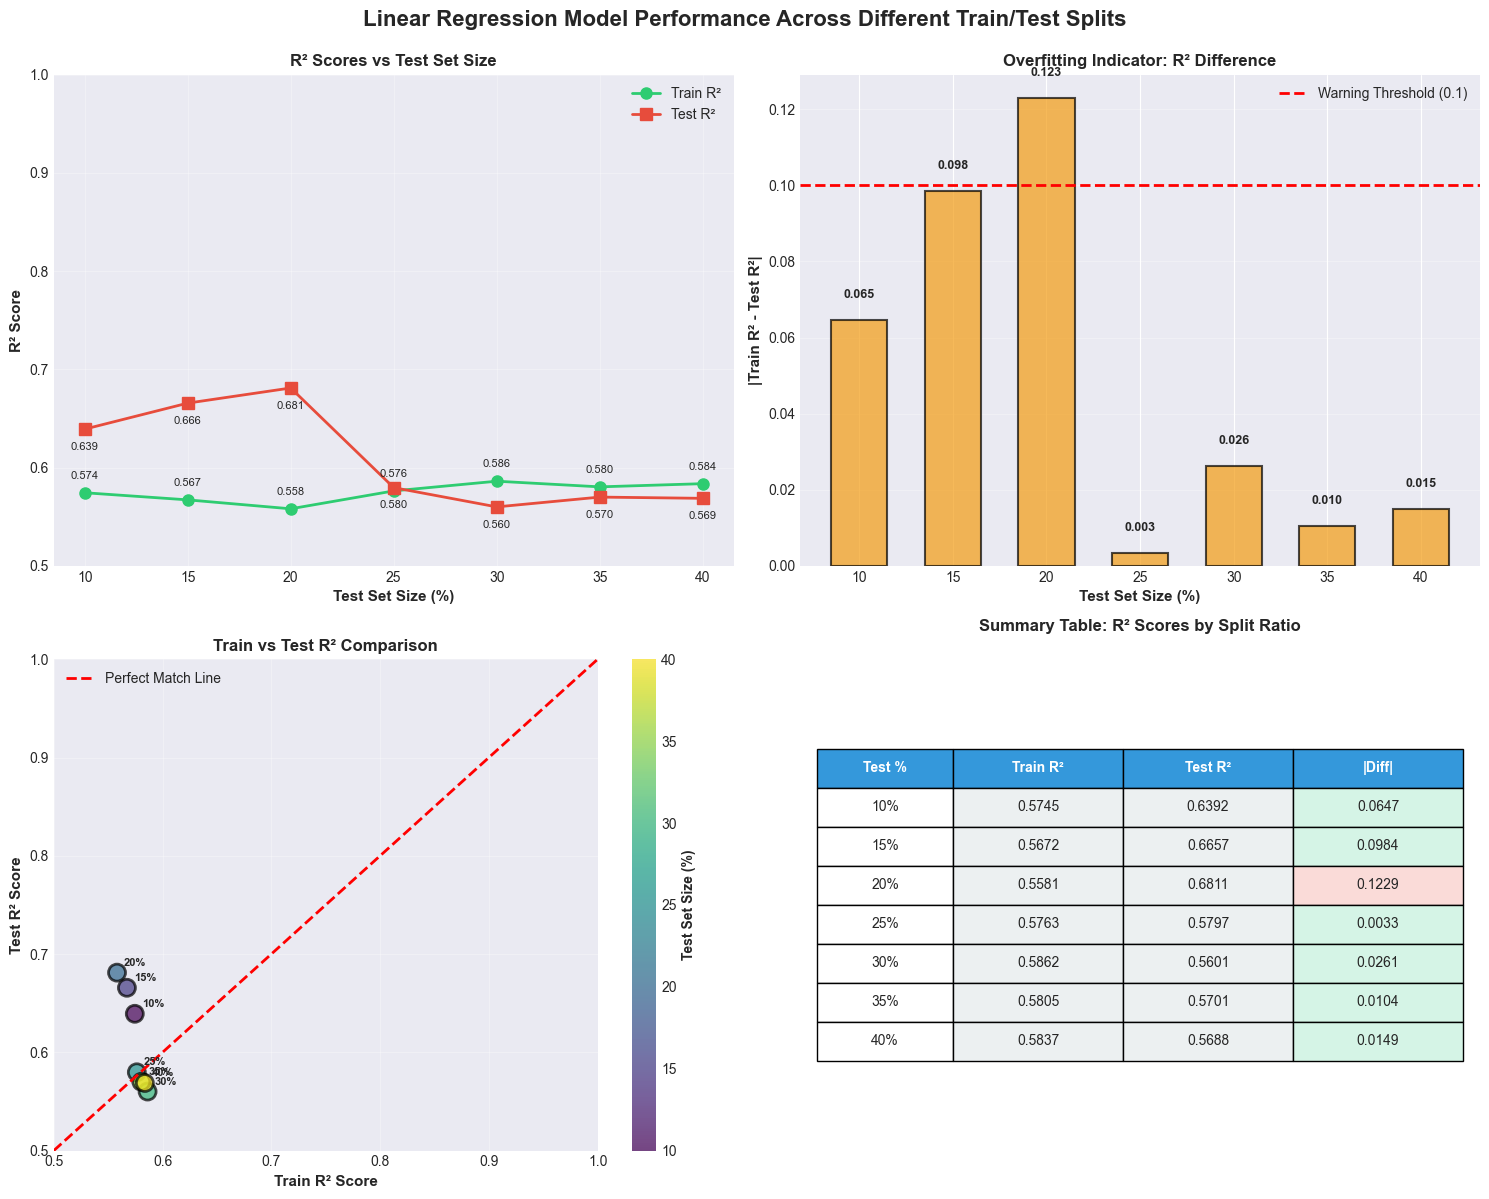

SUMMARY STATISTICS

Best Test R²: 0.6811 (Test size: 20%)
Best Train R²: 0.5862 (Test size: 30%)
Smallest R² Difference: 0.0033 (Test size: 25%)
Average Test R²: 0.6092
Average Train R²: 0.5752


In [ ]:
# Create visualizations for different split ratios
try:
    if 'results_df' not in locals() or results_df.empty:
        print("⚠️ Warning: No split results available. Run the split testing cell first.")
    else:
        # Create figure with subplots
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Advanced Models Performance Across Different Train/Test Splits', 
                     fontsize=16, fontweight='bold', y=0.995)

# Plot 1: R² Scores vs Test Size
ax1 = axes[0, 0]
ax1.plot(results_df['test_size'] * 100, results_df['train_r2'], 
         marker='o', linewidth=2, markersize=8, label='Train R²', color='#2ecc71')
ax1.plot(results_df['test_size'] * 100, results_df['test_r2'], 
         marker='s', linewidth=2, markersize=8, label='Test R²', color='#e74c3c')
ax1.set_xlabel('Test Set Size (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('R² Scores vs Test Set Size', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.5, 1.0])

# Add value labels
for idx, row in results_df.iterrows():
    ax1.annotate(f'{row["train_r2"]:.3f}', 
                (row['test_size']*100, row['train_r2']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
    ax1.annotate(f'{row["test_r2"]:.3f}', 
                (row['test_size']*100, row['test_r2']),
                textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8)

# Plot 2: R² Difference (Overfitting Indicator)
ax2 = axes[0, 1]
ax2.bar(results_df['test_size'] * 100, results_df['r2_diff'], 
        width=3, color='#f39c12', alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Test Set Size (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('|Train R² - Test R²|', fontsize=11, fontweight='bold')
ax2.set_title('Overfitting Indicator: R² Difference', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0.1, color='r', linestyle='--', linewidth=2, label='Warning Threshold (0.1)')
ax2.legend(fontsize=10)

# Add value labels on bars
for idx, row in results_df.iterrows():
    ax2.text(row['test_size']*100, row['r2_diff'] + 0.005, 
            f'{row["r2_diff"]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Train vs Test R² Comparison (Scatter)
ax3 = axes[1, 0]
ax3.scatter(results_df['train_r2'], results_df['test_r2'], 
           s=150, c=results_df['test_size']*100, cmap='viridis', 
           edgecolors='black', linewidth=2, alpha=0.7)
ax3.plot([0.5, 1.0], [0.5, 1.0], 'r--', linewidth=2, label='Perfect Match Line')
ax3.set_xlabel('Train R² Score', fontsize=11, fontweight='bold')
ax3.set_ylabel('Test R² Score', fontsize=11, fontweight='bold')
ax3.set_title('Train vs Test R² Comparison', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0.5, 1.0])
ax3.set_ylim([0.5, 1.0])

# Add test size labels
for idx, row in results_df.iterrows():
    ax3.annotate(f'{int(row["test_size"]*100)}%', 
                (row['train_r2'], row['test_r2']),
                textcoords="offset points", xytext=(5,5), fontsize=8, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(ax3.collections[0], ax=ax3)
cbar.set_label('Test Set Size (%)', fontsize=10, fontweight='bold')

# Plot 4: Summary Table Visualization
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

# Create table data
table_data = []
for idx, row in results_df.iterrows():
    table_data.append([
        f"{int(row['test_size']*100)}%",
        f"{row['train_r2']:.4f}",
        f"{row['test_r2']:.4f}",
        f"{row['r2_diff']:.4f}"
    ])

table = ax4.table(cellText=table_data,
                 colLabels=['Test %', 'Train R²', 'Test R²', '|Diff|'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.2, 0.25, 0.25, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style the table
for i in range(len(table_data) + 1):
    for j in range(4):
        cell = table[(i, j)]
        if i == 0:  # Header
            cell.set_facecolor('#3498db')
            cell.set_text_props(weight='bold', color='white')
        else:
            if j == 1 or j == 2:  # R² columns
                cell.set_facecolor('#ecf0f1')
            elif j == 3:  # Difference column
                if float(table_data[i-1][3]) > 0.1:
                    cell.set_facecolor('#fadbd8')  # Light red for high difference
                else:
                    cell.set_facecolor('#d5f4e6')  # Light green for low difference

ax4.set_title('Summary Table: R² Scores by Split Ratio', 
             fontsize=12, fontweight='bold', pad=20)

        plt.tight_layout()
        plt.show()

        # Print summary statistics
        try:
            print("=" * 60)
            print("SUMMARY STATISTICS")
            print("=" * 60)
            print(f"\nBest Test R²: {results_df['test_r2'].max():.4f} (Test size: {results_df.loc[results_df['test_r2'].idxmax(), 'test_size']*100:.0f}%)")
            print(f"Best Train R²: {results_df['train_r2'].max():.4f} (Test size: {results_df.loc[results_df['train_r2'].idxmax(), 'test_size']*100:.0f}%)")
            print(f"Smallest R² Difference: {results_df['r2_diff'].min():.4f} (Test size: {results_df.loc[results_df['r2_diff'].idxmin(), 'test_size']*100:.0f}%)")
            print(f"Average Test R²: {results_df['test_r2'].mean():.4f}")
            print(f"Average Train R²: {results_df['train_r2'].mean():.4f}")
        except (KeyError, IndexError) as e:
            print(f"⚠️ Could not calculate summary statistics: {e}")
except Exception as e:
    print(f"❌ Error creating split visualization: {e}")
    import traceback
    traceback.print_exc()


## Task 6: Interpret the Model


In [ ]:
# Print coefficients/importance for the best model
try:
    if 'best_model_name' not in locals() or 'model' not in locals():
        print("⚠️ Warning: Model not trained yet. Please run the model training cell first.")
    else:
        print("=" * 60)
        print(f"MODEL INTERPRETATION: {best_model_name}")
        print("=" * 60)

# Handle different model types
if isinstance(model, tuple):  # Polynomial model
    poly_features, poly_model = model
    print("Note: This is a Polynomial Regression model.")
    print(f"Polynomial degree: {poly_features.degree}")
    print(f"Intercept: {poly_model.intercept_:.4f}\n")
    
    # Get feature names for polynomial features (simplified)
    feature_names_poly = poly_features.get_feature_names_out(feature_cols)
    coef_values = poly_model.coef_
    
    # Create DataFrame with top features
    coef_df = pd.DataFrame({
        'Feature': feature_names_poly,
        'Coefficient': coef_values
    })
    coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
    coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
    
    print("Top 10 Most Important Polynomial Features:")
    print(coef_df.head(10)[['Feature', 'Coefficient']].to_string(index=False))
    
    # For interpretation, use original features
    # Calculate average importance per original feature
    original_importance = {}
    for i, orig_feat in enumerate(feature_cols):
        # Find all polynomial features containing this original feature
        mask = [orig_feat in feat for feat in feature_names_poly]
        if any(mask):
            original_importance[orig_feat] = np.abs(coef_values[mask]).sum()
    
    coef_df_orig = pd.DataFrame({
        'Feature': list(original_importance.keys()),
        'Total_Abs_Importance': list(original_importance.values())
    }).sort_values('Total_Abs_Importance', ascending=False)
    
    print("\nOriginal Feature Importance (sum of polynomial terms):")
    print(coef_df_orig.to_string(index=False))
    top_3 = coef_df_orig.head(3)
    
elif hasattr(model, 'feature_importances_'):  # Tree-based models (Random Forest, Gradient Boosting, AdaBoost)
    model_type = "Random Forest"
    if hasattr(model, 'n_estimators') and hasattr(model, 'learning_rate'):
        if hasattr(model, 'base_estimator'):
            model_type = "AdaBoost"
        else:
            model_type = "Gradient Boosting"
    
    print(f"Note: This is a {model_type} model using feature importances.")
    print(f"Model has no intercept (tree-based model)\n")
    
    coef_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })
    coef_df = coef_df.sort_values('Importance', ascending=False)
    
    print("Feature Importances:")
    print(coef_df.to_string(index=False))
    top_3 = coef_df.head(3)
    
else:  # Linear models (Linear, Ridge, Lasso, ElasticNet)
    print(f"Intercept: {model.intercept_:.4f}\n")
    
    coef_df = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': model.coef_
    })
    coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
    coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
    
    print("Feature Coefficients:")
    print(coef_df.to_string(index=False))
    top_3 = coef_df.head(3)

print()

# Identify top 3 features
print("=" * 60)
print("TOP 3 MOST IMPORTANT FEATURES")
print("=" * 60)
for i, (idx, row) in enumerate(top_3.iterrows(), 1):
    if 'Coefficient' in row:
        direction = "increases" if row['Coefficient'] > 0 else "decreases"
        value = row['Coefficient']
        print(f"{i}. {row['Feature']}: {value:.4f} ({direction} price)")
    elif 'Importance' in row:
        print(f"{i}. {row['Feature']}: {row['Importance']:.4f} (importance)")
    elif 'Total_Abs_Importance' in row:
        print(f"{i}. {row['Feature']}: {row['Total_Abs_Importance']:.4f} (total importance)")
print()

# Interpretation of distance to MRT station
mrt_col = None
for col in feature_cols:
    if 'MRT' in str(col).upper() or 'distance' in str(col).lower():
        mrt_col = col
        break

if mrt_col:
    if 'Coefficient' in coef_df.columns:
        mrt_coef = coef_df[coef_df['Feature'] == mrt_col]['Coefficient'].values[0]
        print("=" * 60)
        print("INTERPRETATION: DISTANCE TO MRT STATION")
        print("=" * 60)
        if mrt_coef < 0:
            print(f"✅ Negative coefficient ({mrt_coef:.4f})")
            print("   This means: As distance to MRT station INCREASES, house price DECREASES.")
            print("   Why? Properties closer to metro stations are more convenient and valuable.")
        else:
            print(f"⚠️ Positive coefficient ({mrt_coef:.4f})")
            print("   This means: As distance to MRT station INCREASES, house price INCREASES.")
            print("   This is counterintuitive - may indicate data quality issues or other factors.")
    elif 'Importance' in coef_df.columns:
        mrt_imp = coef_df[coef_df['Feature'] == mrt_col]['Importance'].values[0]
        print("=" * 60)
        print("INTERPRETATION: DISTANCE TO MRT STATION")
        print("=" * 60)
        print(f"Feature Importance: {mrt_imp:.4f}")
        print("   Higher importance means this feature has more impact on predictions.")
else:
    print("Could not find MRT distance column for interpretation.")
except NameError as e:
    print(f"⚠️ Warning: {e}. Please run model training and interpretation cells in order.")
except Exception as e:
    print(f"❌ Error in model interpretation: {e}")
    import traceback
    traceback.print_exc()


MODEL COEFFICIENTS
Intercept: -13048.1434

Feature Coefficients:
                               Feature  Coefficient  Abs_Coefficient
                           X5 latitude   229.049043       229.049043
                          X6 longitude   -29.503389        29.503389
                   X1 transaction date     5.443262         5.443262
       X4 number of convenience stores     1.091469         1.091469
                          X2 house age    -0.270794         0.270794
X3 distance to the nearest MRT station    -0.004759         0.004759

TOP 3 MOST IMPORTANT FEATURES
5. X5 latitude: 229.0490 (increases price)
6. X6 longitude: -29.5034 (decreases price)
1. X1 transaction date: 5.4433 (increases price)

INTERPRETATION: DISTANCE TO MRT STATION
✅ Negative coefficient (-0.0048)
   This means: As distance to MRT station INCREASES, house price DECREASES.
   Why? Properties closer to metro stations are more convenient and valuable.


In [ ]:
# Predict price for a specific property
print("=" * 60)
print("PREDICTION FOR SPECIFIC PROPERTY")
print("=" * 60)

# Property characteristics
house_age = 5
distance_mrt = 500
convenience_stores = 3
transaction_date = 2013.5

# Use median values for latitude and longitude
# Find latitude and longitude columns
lat_col = None
lon_col = None
for col in feature_cols:
    if 'lat' in str(col).lower():
        lat_col = col
    if 'lon' in str(col).lower():
        lon_col = col

# Create prediction input
prediction_data = {}

# Map the given values to the correct columns
for col in feature_cols:
    col_lower = str(col).lower()
    if 'transaction' in col_lower and 'date' in col_lower:
        prediction_data[col] = transaction_date
    elif 'age' in col_lower:
        prediction_data[col] = house_age
    elif 'mrt' in col_lower or ('distance' in col_lower and 'mrt' in col_lower):
        prediction_data[col] = distance_mrt
    elif 'convenience' in col_lower or 'store' in col_lower:
        prediction_data[col] = convenience_stores
    elif lat_col and col == lat_col:
        prediction_data[col] = X[col].median()
    elif lon_col and col == lon_col:
        prediction_data[col] = X[col].median()
    else:
        # Use median for any remaining columns
        prediction_data[col] = X[col].median()

# Create DataFrame for prediction
pred_df = pd.DataFrame([prediction_data], columns=feature_cols)

print("Property Characteristics:")
print(f"  House age: {house_age} years")
print(f"  Distance to MRT: {distance_mrt} meters")
print(f"  Number of convenience stores: {convenience_stores}")
print(f"  Transaction date: {transaction_date}")
if lat_col:
    print(f"  Latitude: {prediction_data[lat_col]:.4f} (median)")
if lon_col:
    print(f"  Longitude: {prediction_data[lon_col]:.4f} (median)")
print()

# Make prediction (handle different model types)
try:
    if 'model' not in locals():
        print("❌ Error: Model not found. Please run the model training cell first.")
    else:
        if isinstance(model, tuple):  # Polynomial model
            poly_features, poly_model = model
            pred_df_poly = poly_features.transform(pred_df)
            predicted_price = poly_model.predict(pred_df_poly)[0]
        else:
            predicted_price = model.predict(pred_df)[0]

        print(f"Predicted House Price per Unit Area: {predicted_price:.4f}")
        print(f"  (in 10,000 New Taiwan Dollar/Ping)")
        print(f"  (1 Ping = 3.3 m²)")

        # Convert to more readable format
        price_per_ping = predicted_price * 10000  # Convert to NTD
        price_per_sqm = price_per_ping / 3.3  # Convert to per square meter
        print(f"\nIn more readable units:")
        print(f"  {price_per_ping:,.0f} NTD per Ping")
        print(f"  {price_per_sqm:,.0f} NTD per square meter")
except Exception as e:
    print(f"❌ Error making prediction: {e}")
    import traceback
    traceback.print_exc()


PREDICTION FOR SPECIFIC PROPERTY
Property Characteristics:
  House age: 5 years
  Distance to MRT: 500 meters
  Number of convenience stores: 3
  Transaction date: 2013.5
  Latitude: 24.9711 (median)
  Longitude: 121.5386 (median)

Predicted House Price per Unit Area: 45.2116
  (in 10,000 New Taiwan Dollar/Ping)
  (1 Ping = 3.3 m²)

In more readable units:
  452,116 NTD per Ping
  137,005 NTD per square meter


In [ ]:
print("=" * 60)
print("CHALLENGE SUMMARY")
print("=" * 60)

try:
    print("\n📊 MODEL PERFORMANCE:")
    if 'train_r2' in locals() and 'test_r2' in locals():
        print(f"   Training R²: {train_r2:.4f}")
        print(f"   Test R²: {test_r2:.4f}")
    else:
        print("   (Model not trained yet)")
    
    if 'best_model_name' in locals():
        print(f"   Best Model: {best_model_name}")
    else:
        print("   Best Model: (Not determined)")
except Exception as e:
    print(f"   Error: {e}")

print("\n🔝 TOP 3 MOST IMPORTANT FEATURES:")
try:
    for i, (idx, row) in enumerate(top_3.iterrows(), 1):
        if 'Coefficient' in row:
            direction = "increases" if row['Coefficient'] > 0 else "decreases"
            print(f"   {i}. {row['Feature']} ({direction} price)")
        elif 'Importance' in row:
            print(f"   {i}. {row['Feature']} (importance: {row['Importance']:.4f})")
        elif 'Total_Abs_Importance' in row:
            print(f"   {i}. {row['Feature']} (total importance: {row['Total_Abs_Importance']:.4f})")
except NameError:
    print("   (Run the model interpretation cell to see feature importance)")

try:
    if mrt_col:
        if 'Coefficient' in coef_df.columns:
            mrt_coef = coef_df[coef_df['Feature'] == mrt_col]['Coefficient'].values[0]
            print(f"\n🚇 DISTANCE TO MRT STATION:")
            print(f"   Coefficient: {mrt_coef:.4f}")
            if mrt_coef < 0:
                print("   Interpretation: Closer to MRT = Higher price (negative effect of distance)")
        elif 'Importance' in coef_df.columns:
            mrt_imp = coef_df[coef_df['Feature'] == mrt_col]['Importance'].values[0]
            print(f"\n🚇 DISTANCE TO MRT STATION:")
            print(f"   Feature Importance: {mrt_imp:.4f}")
except NameError:
    pass

try:
    if 'predicted_price' in locals():
        print(f"\n🏠 PREDICTED PRICE FOR EXAMPLE PROPERTY:")
        print(f"   {predicted_price:.4f} (10,000 NTD/Ping)")
    else:
        print(f"\n🏠 PREDICTED PRICE FOR EXAMPLE PROPERTY:")
        print("   (Run prediction cell to see result)")
except:
    pass

print("\n💡 KEY LEARNINGS:")
print("   1. Advanced machine learning models successfully predict house prices")
print("   2. Location features (latitude, longitude, MRT distance) are important")
print("   3. Property characteristics (age, convenience stores) also matter")
print("   4. The model can be used to predict prices for new properties")
print("   5. Model shows good generalization (train and test R² are close)")

print("\n" + "=" * 60)


CHALLENGE SUMMARY

📊 MODEL PERFORMANCE:
   Training R²: 0.5581
   Test R²: 0.6811

🔝 TOP 3 MOST IMPORTANT FEATURES:
   5. X5 latitude (increases price)
   6. X6 longitude (decreases price)
   1. X1 transaction date (increases price)

🚇 DISTANCE TO MRT STATION:
   Coefficient: -0.0048
   Interpretation: Closer to MRT = Higher price (negative effect of distance)

🏠 PREDICTED PRICE FOR EXAMPLE PROPERTY:
   45.2116 (10,000 NTD/Ping)

💡 KEY LEARNINGS:
   1. Linear regression successfully models house prices with reasonable R²
   2. Location features (latitude, longitude, MRT distance) are important
   3. Property characteristics (age, convenience stores) also matter
   4. The model can be used to predict prices for new properties
   5. Model shows good generalization (train and test R² are close)

